# C任务：PyTorch深度学习回归预测

本Notebook基于A同学清洗后的 `AmesHousing_Cleaned.csv`，使用PyTorch搭建MLP回归网络，并输出测试集RMSE、R2及报告图表。为避免目标泄露，输入特征会同时删除 `SalePrice` 和 `LogSalePrice`，目标变量使用 `LogSalePrice`。

In [1]:
import sys
import torch
import pandas as pd
from IPython.display import Image, display

print('Python:', sys.version)
print('PyTorch:', torch.__version__)

Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
PyTorch: 2.12.0+cu126


## 1. 训练MLP模型

运行下面单元会重新执行 `deep_model.py`：完成数据划分、预处理、MLP调参、早停训练、测试集评估和图表导出。

In [2]:
import deep_model

deep_model.main()

Using device: cuda


Rows: 2930, raw features: 90, encoded features: 323

Training MLP_small...


MLP_small: val RMSE=0.111054, test RMSE=0.114226, test R2=0.912788

Training MLP_medium...


MLP_medium: val RMSE=0.110401, test RMSE=0.113032, test R2=0.914603

Training MLP_regularized...


MLP_regularized: val RMSE=0.111738, test RMSE=0.119083, test R2=0.905215



Best model: MLP_medium
Test RMSE(log): 0.113032
Test R2(log): 0.914603
Artifacts saved to: output\deep_model


## 2. 调参结果与模型对比

In [3]:
tuning = pd.read_csv('output/deep_model/mlp_tuning_results.csv')
comparison = pd.read_csv('output/deep_model/model_comparison.csv')
display(tuning)
display(comparison)

,model,hidden_dims,dropout,learning_rate,weight_decay,batch_size,epochs_ran,best_val_rmse_log,test_rmse_log,test_r2_log
0,MLP_small,"(128, 64)",0.10,0.0010,0.00001,64,63,0.111054,0.114226,0.912788
1,MLP_medium,"(256, 128, 64)",0.15,0.0008,0.00001,64,76,0.110401,0.113032,0.914603
2,MLP_regularized,"(256, 128)",0.25,0.0008,0.00010,64,56,0.111738,0.119083,0.905215


,model,rmse_log,r2_log,source
0,Lasso,0.010943,0.999319,traditional-model branch
1,RandomForest,0.001622,0.999985,traditional-model branch
2,LightGBM,0.018581,0.998036,traditional-model branch
3,MLP_medium,0.113032,0.914603,deep-model branch


## 3. 结果可视化

output/deep_model/01_training_curve.png


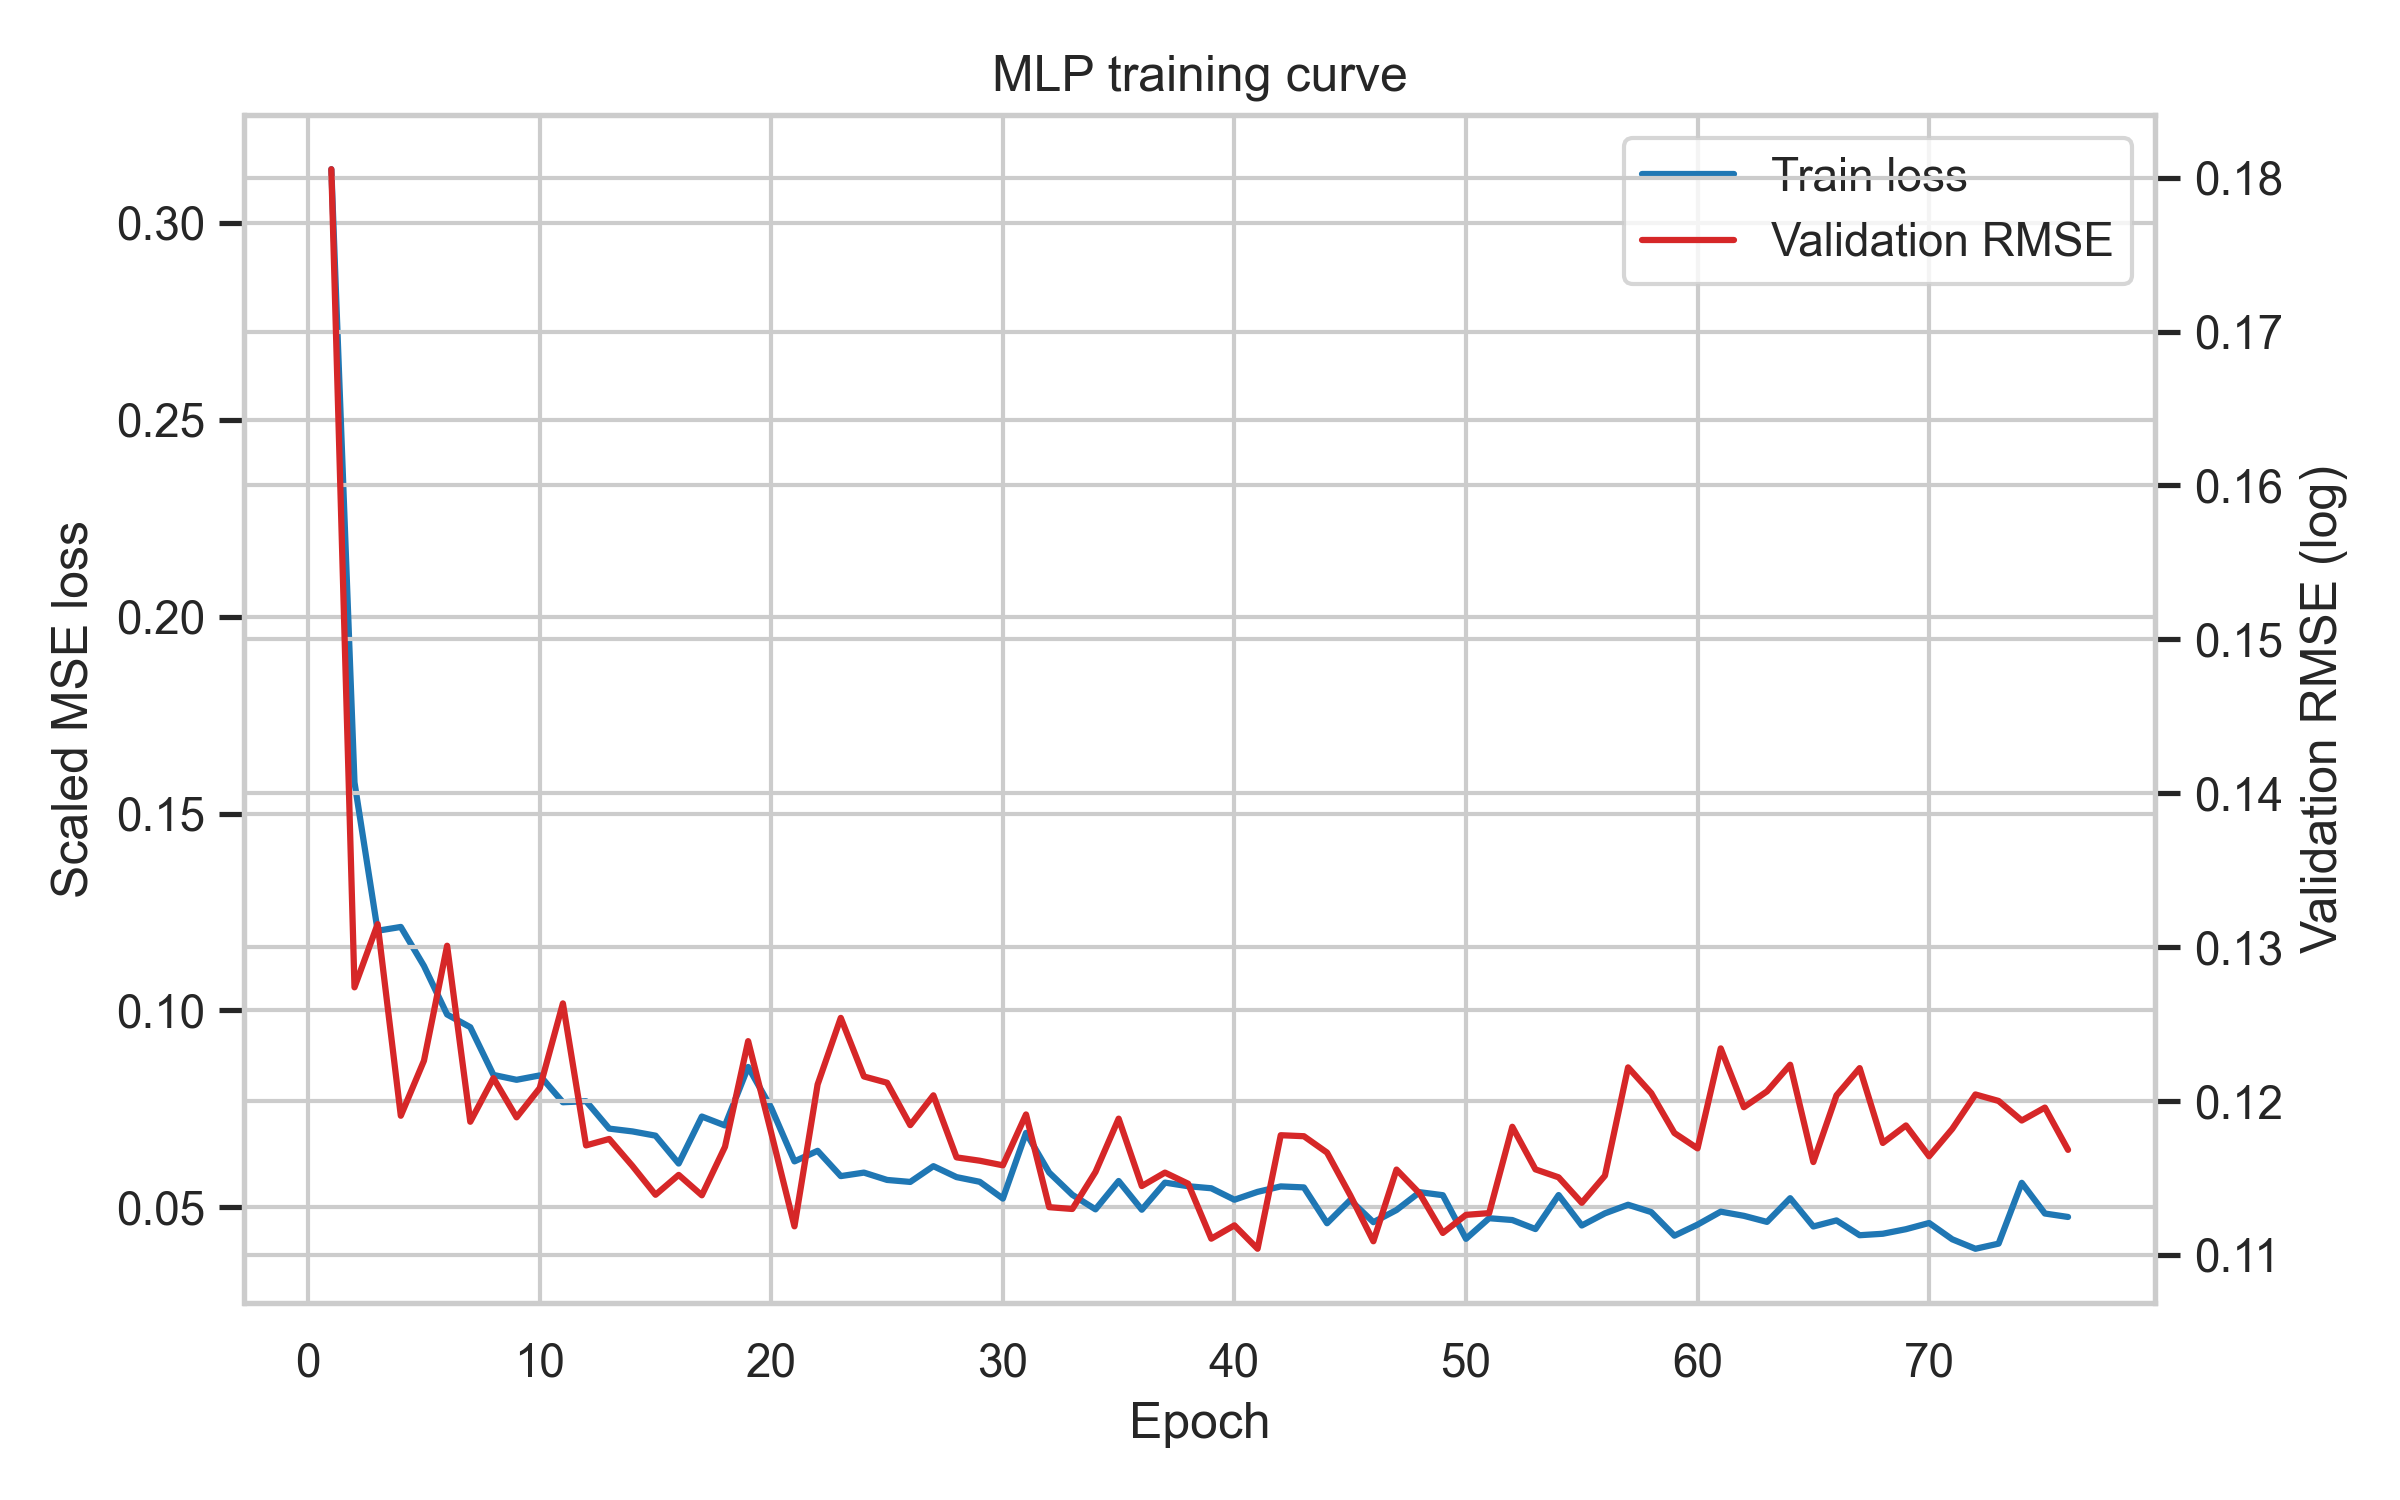

output/deep_model/02_prediction_vs_true.png


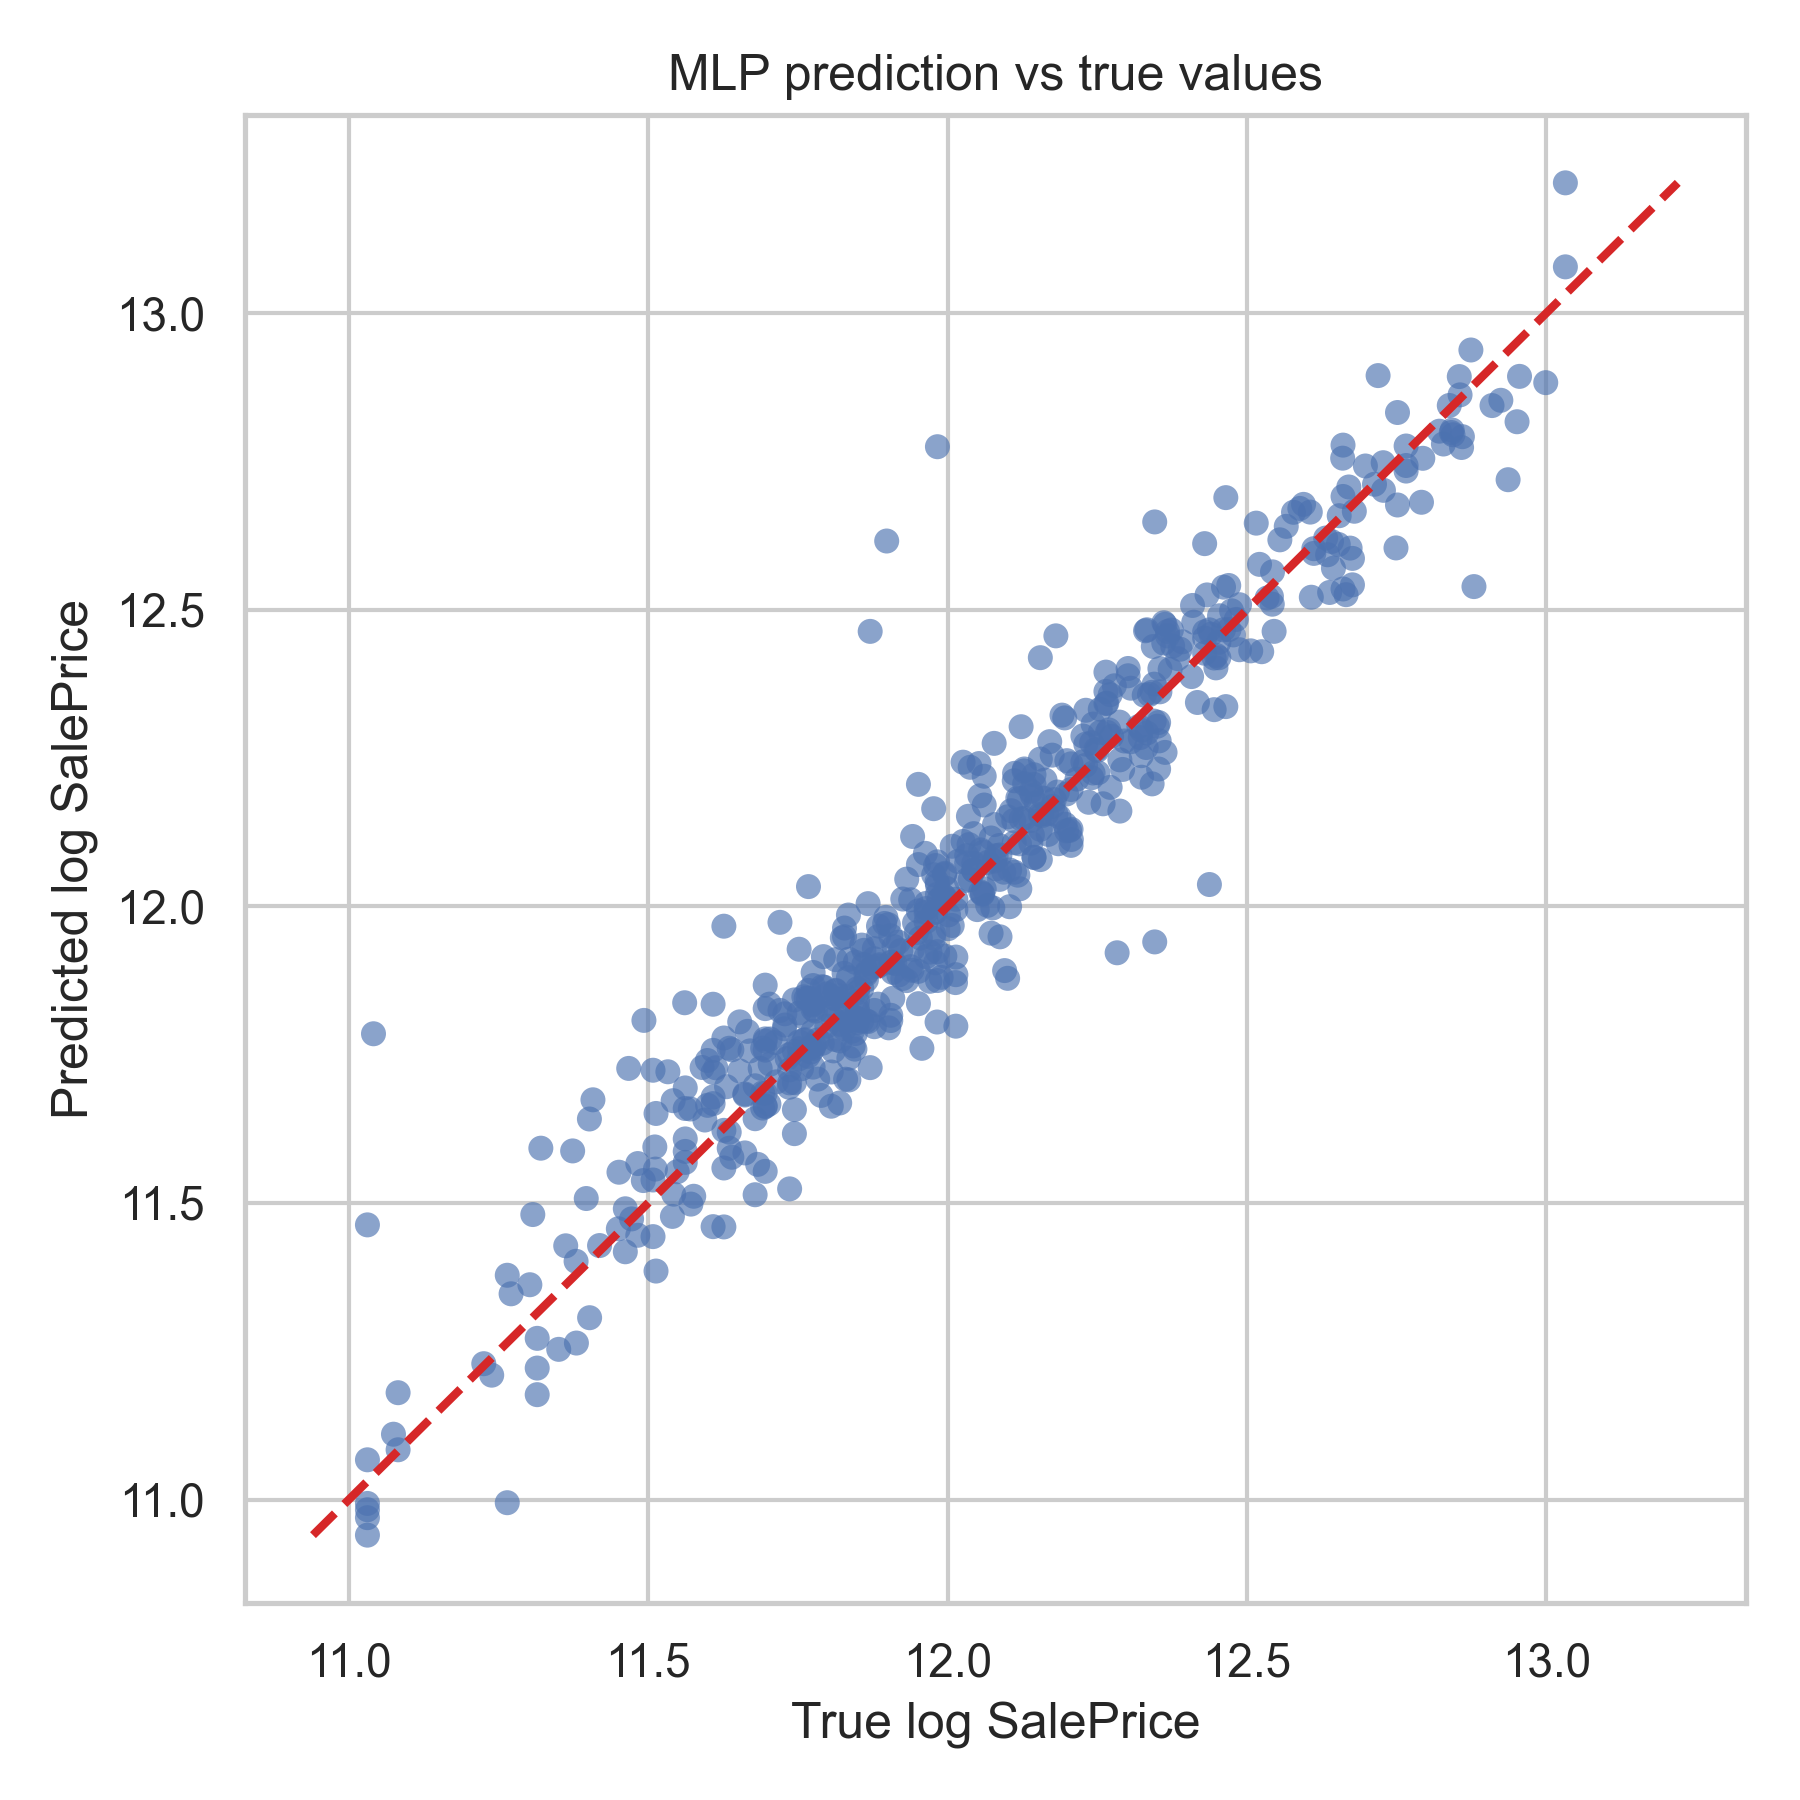

output/deep_model/03_residual_plot.png


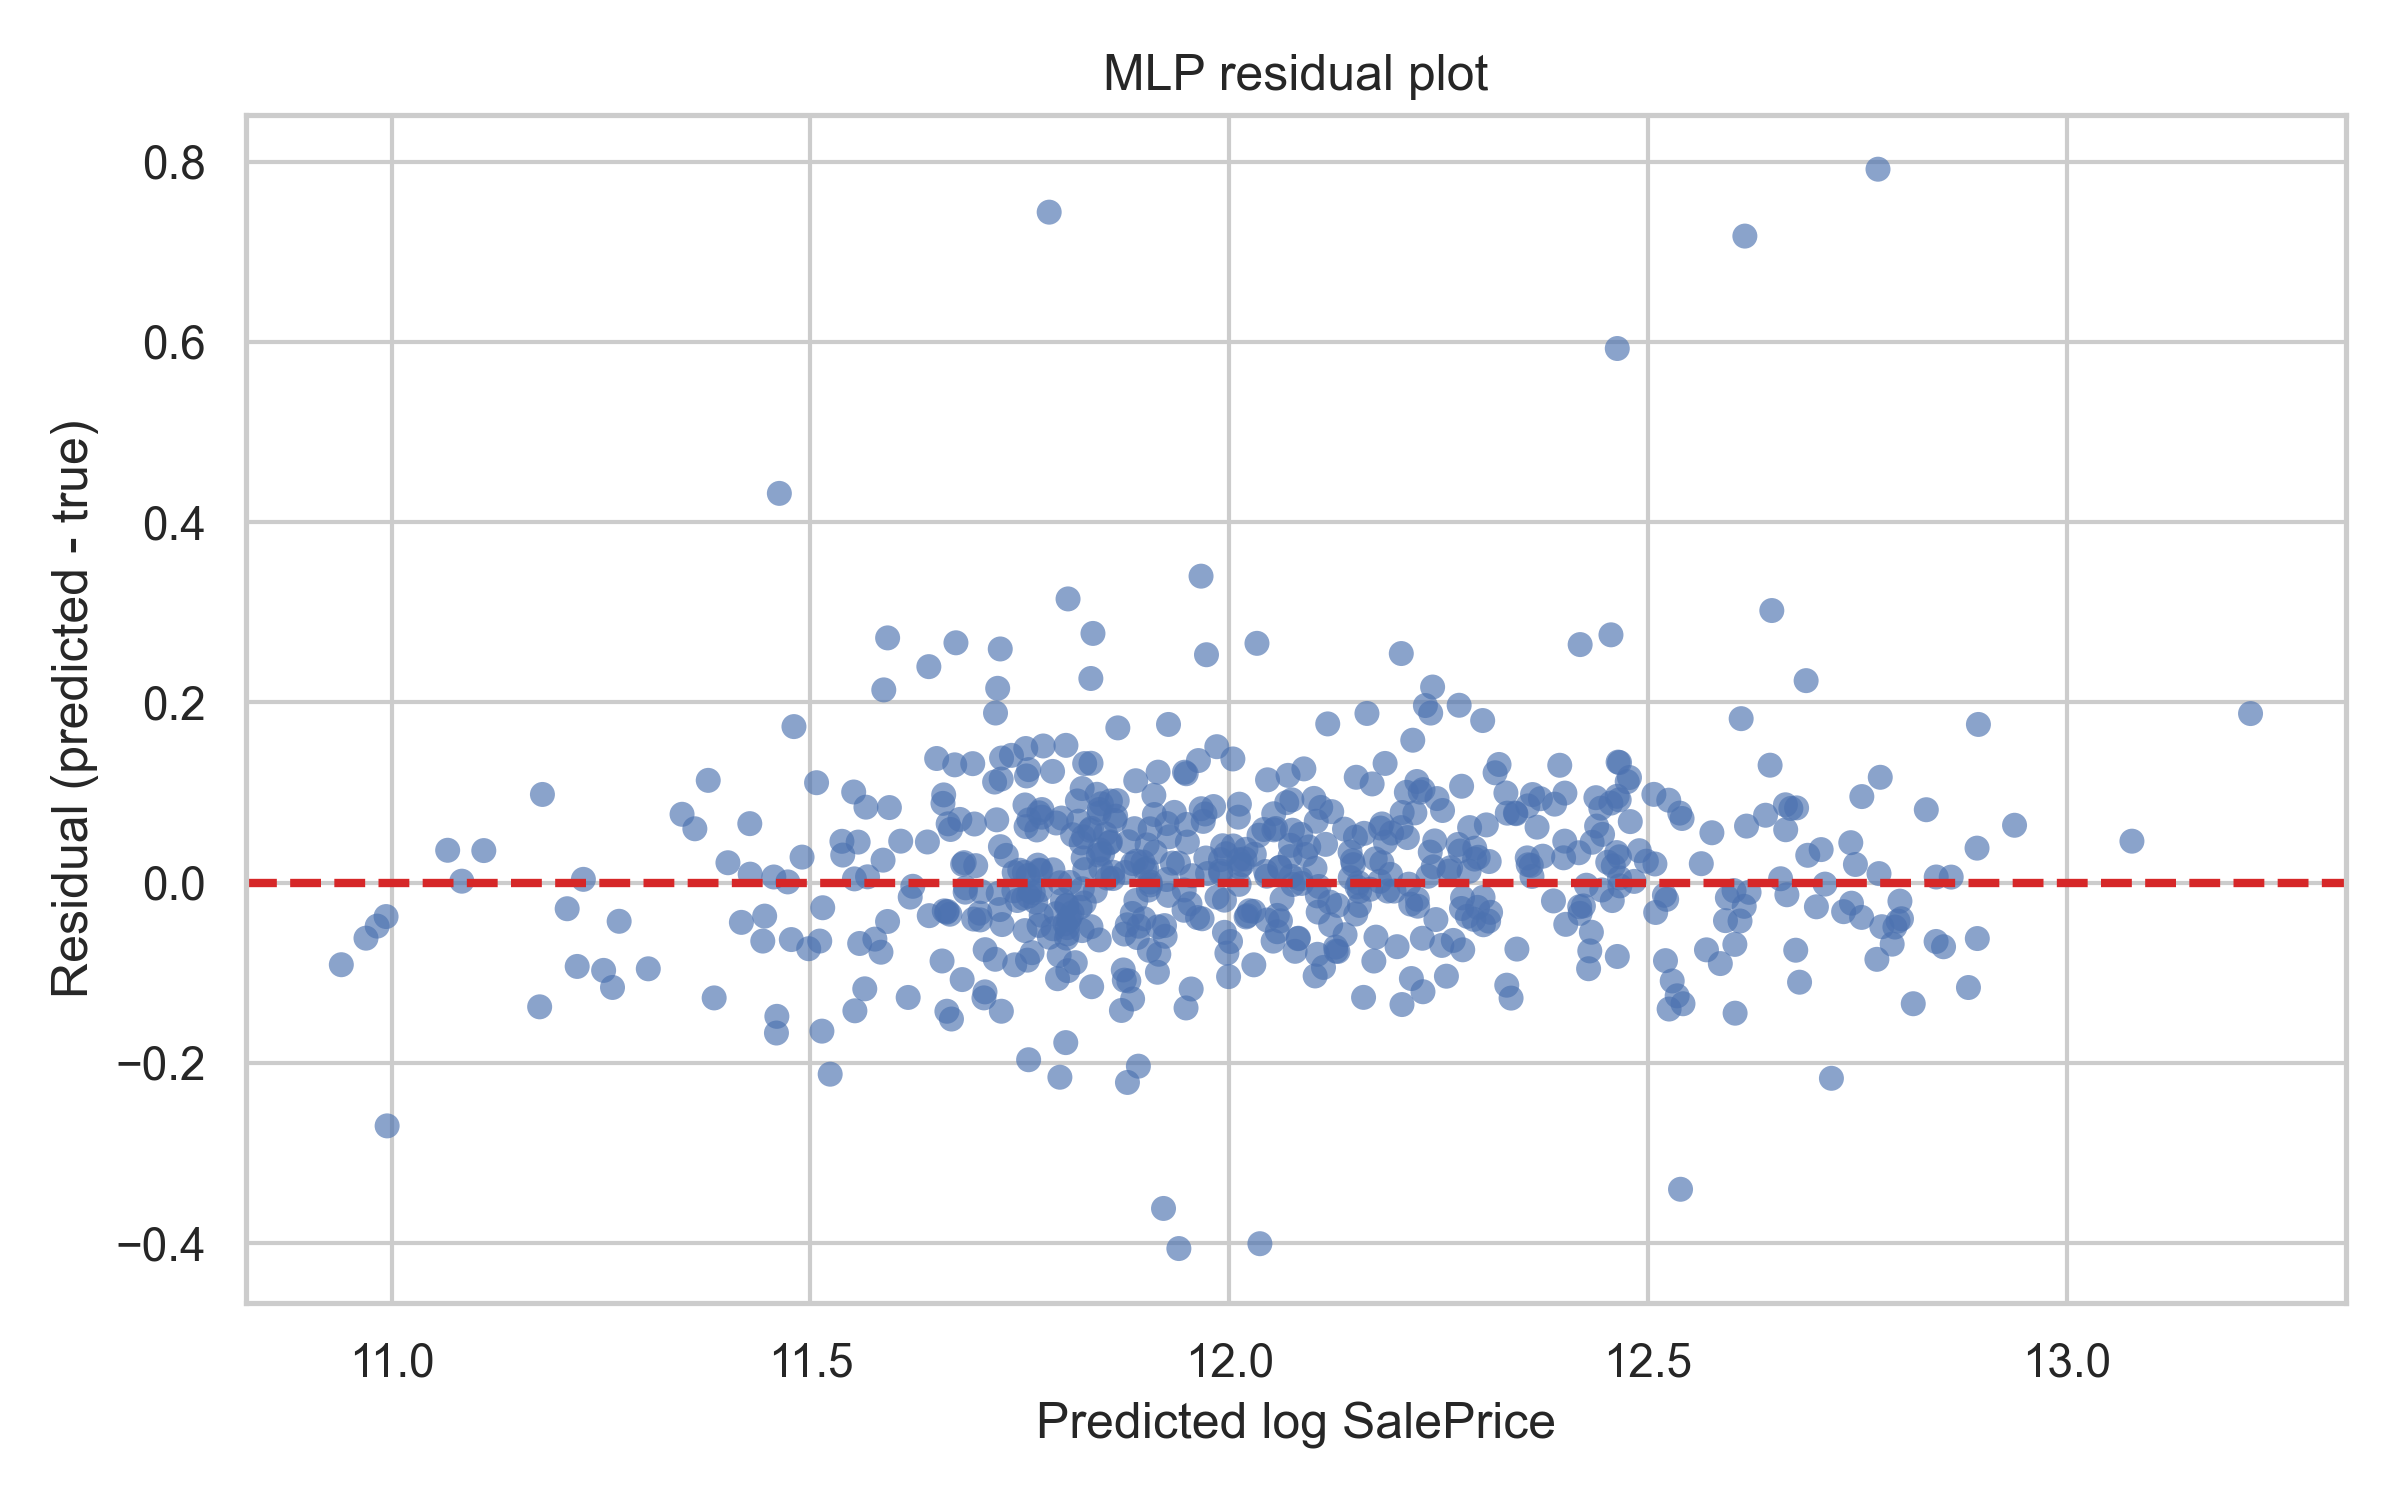

output/deep_model/04_model_comparison.png


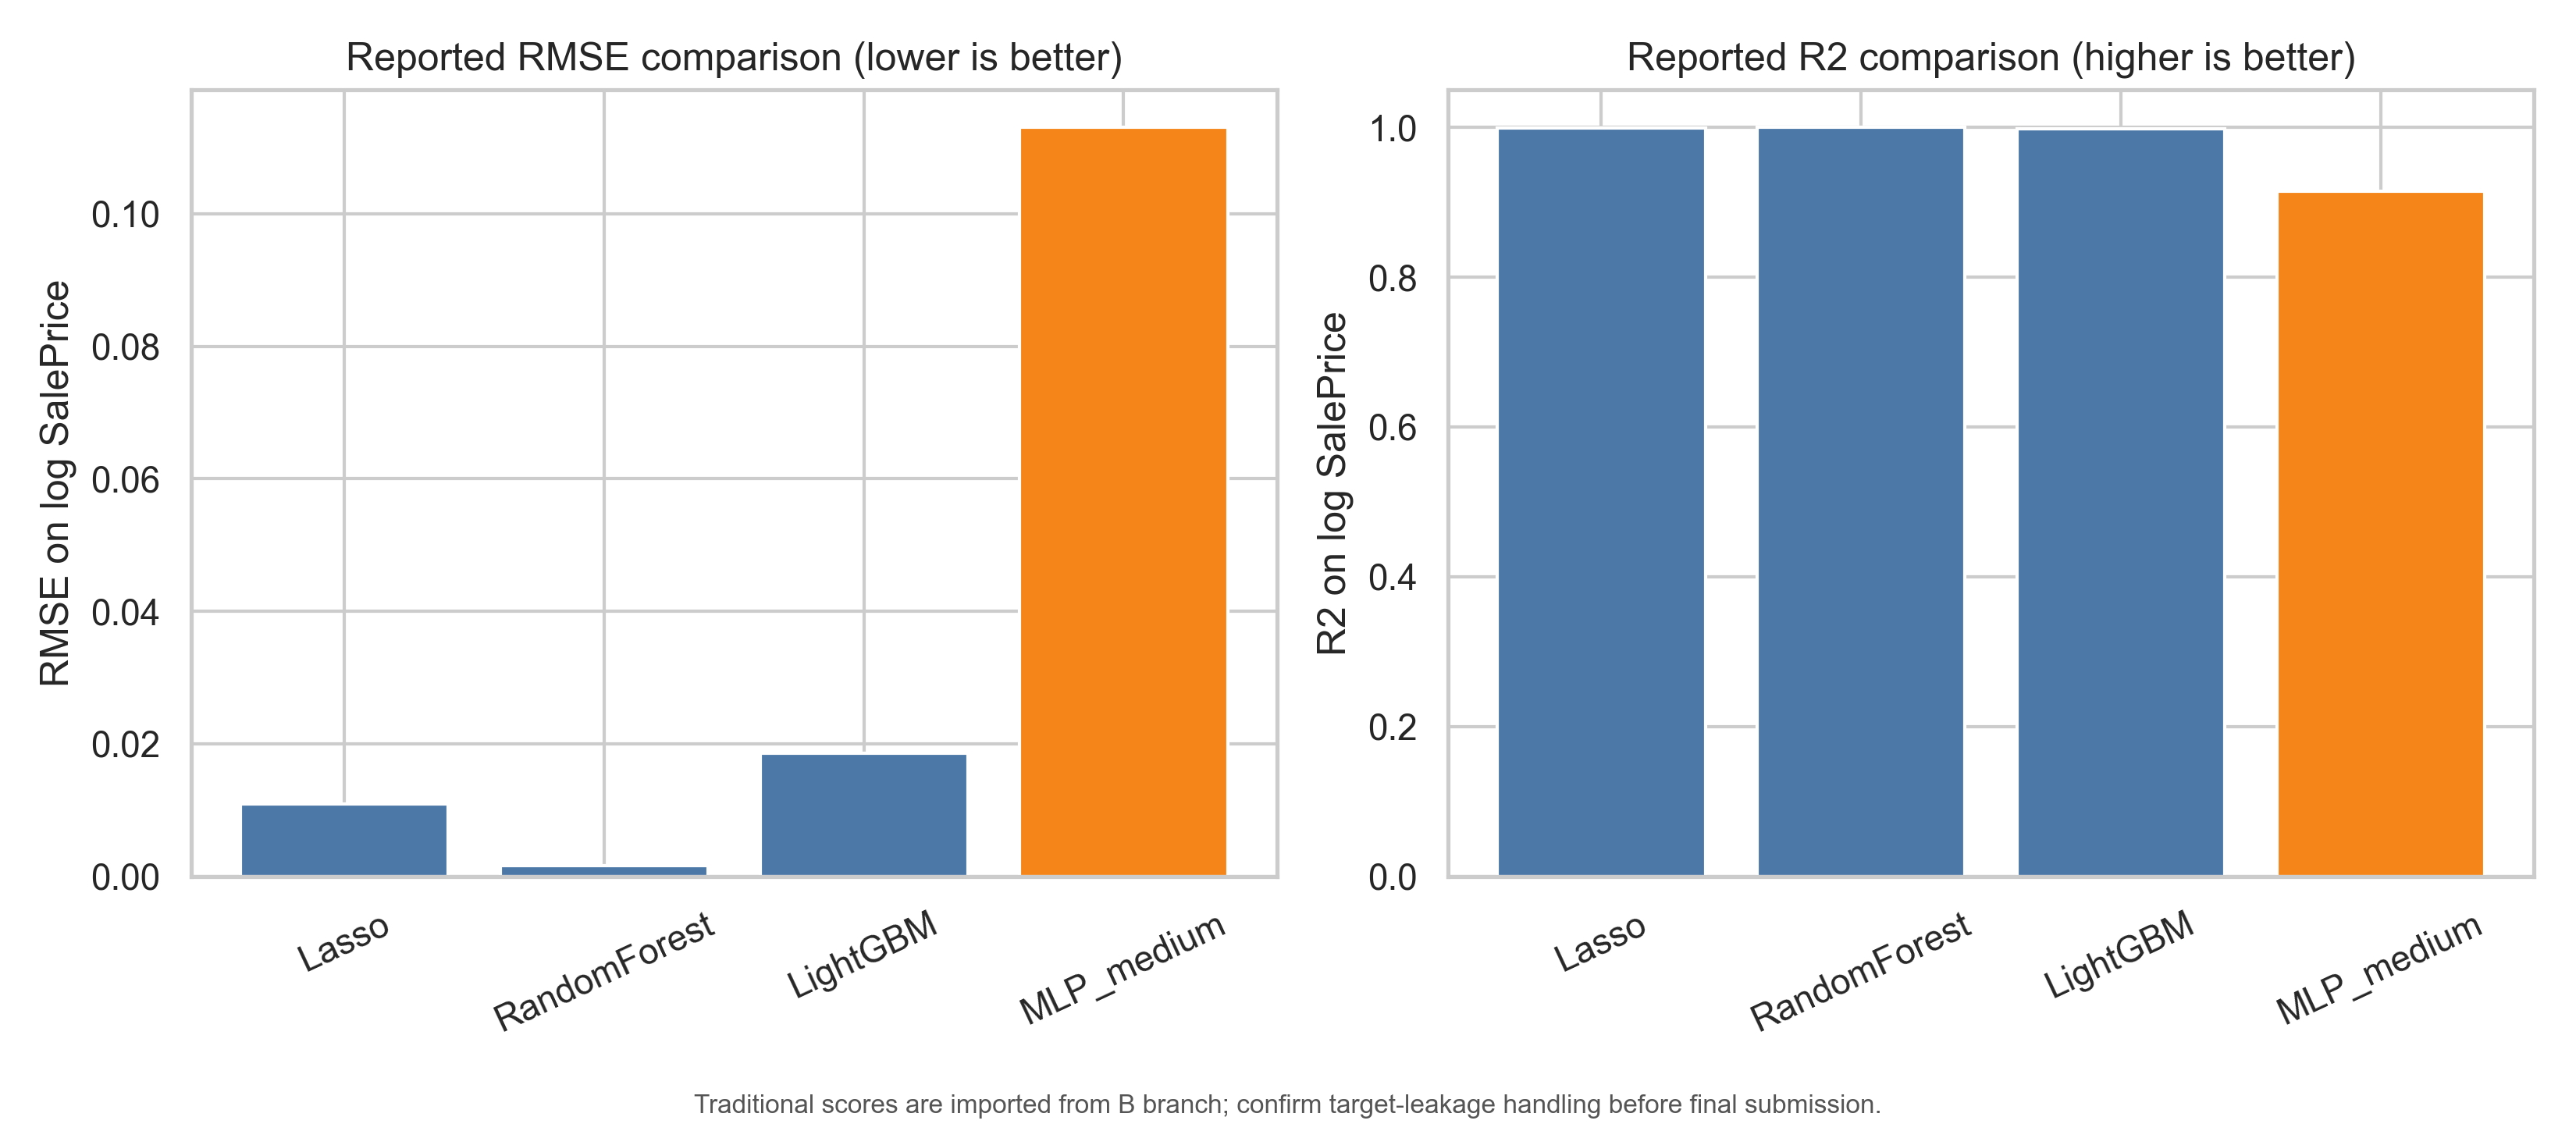

In [4]:
for path in [
    'output/deep_model/01_training_curve.png',
    'output/deep_model/02_prediction_vs_true.png',
    'output/deep_model/03_residual_plot.png',
    'output/deep_model/04_model_comparison.png',
]:
    print(path)
    display(Image(filename=path))

## 4. 报告整合材料

C部分报告文字已生成到 `report/C_deep_learning_report.md`，可复制到最终项目报告中。